In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path(".")
TASK_FILE = BASE_DIR / "onet_tasks.csv"
EMPLOYMENT_FILE = BASE_DIR / "Eurostat_employment_isco.xlsx"

COUNTRIES = ["Belgium", "Spain", "Poland"]
ISCO_LEVELS = list(range(1, 10))

# Import data from the O*NET database, at ISCO-08 occupation level.
# The original data uses a version of SOC classification, but the data we load here are already cross-walked to ISCO-08.

task_data = pd.read_csv(TASK_FILE)

# Read employment data from Eurostat
isco_data = {}
for level in ISCO_LEVELS:
    isco_data[level] = pd.read_excel(EMPLOYMENT_FILE, sheet_name=f"ISCO{level}")

# This will calculate worker totals in each of the chosen countries.
total_by_country = {}
for country in COUNTRIES:
    total_by_country[country] = sum(isco_data[level][country] for level in ISCO_LEVELS)

In [11]:
# Let's merge all these datasets. We'll need a column that stores occupation categories.
for level in ISCO_LEVELS:
    isco_data[level]["ISCO"] = level

# This gives us one large file with employment in all occupations.
all_data = pd.concat([isco_data[level] for level in ISCO_LEVELS], ignore_index=True)

# We have 9 occupations and the same time range for each, so we can add totals
number_of_isco_groups = len(ISCO_LEVELS)

for country in COUNTRIES:
    all_data[f"total_{country}"] = pd.concat(
        [total_by_country[country]] * number_of_isco_groups,
        ignore_index=True)
    all_data[f"share_{country}"] = all_data[country] / all_data[f"total_{country}"]

In [13]:
# Now let's look at the task data. We want the first digit of the ISCO variable only.
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# Calculate mean task values at a 1-digit level.
aggdata = task_data.groupby("isco08_1dig").mean(numeric_only=True)
aggdata = aggdata.drop(columns=["isco08"])

# Let's combine the data.
combined = pd.merge(all_data, aggdata, left_on="ISCO", right_on="isco08_1dig", how="left")

# Traditionally, the first step is to standardise task values using weights defined by share of occupations in the labour force.
# This should be done separately for each country.

def weighted_standardize(values, weights):
    temp_mean = np.average(values, weights=weights)
    temp_sd = np.sqrt(np.average((values - temp_mean) ** 2, weights=weights))
    return (values - temp_mean) / temp_sd

In [15]:
# We'll be interested in tracking the intensity of Non-routine cognitive analytical tasks.

task_variables = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

for task in task_variables:
    for country in COUNTRIES:
        combined[f"std_{country}_{task}"] = weighted_standardize(
            combined[task],
            combined[f"share_{country}"])

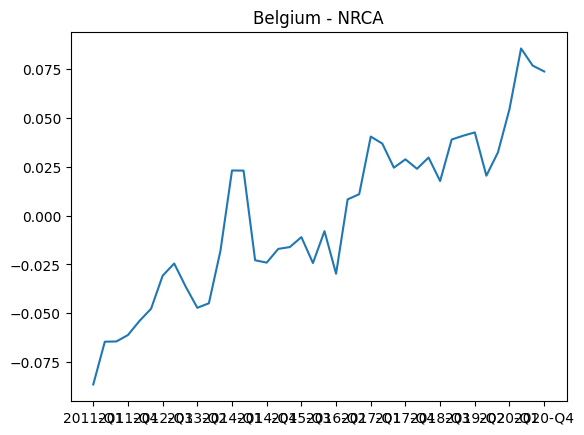

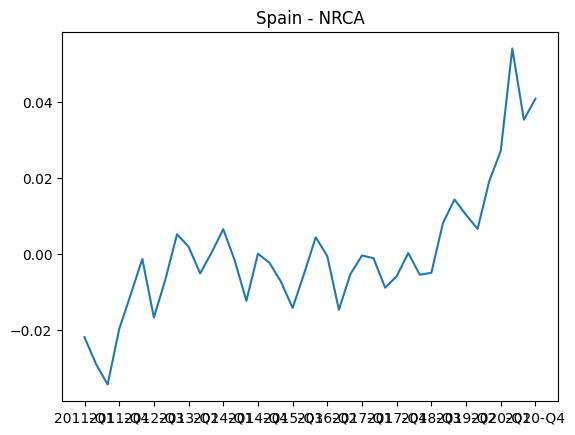

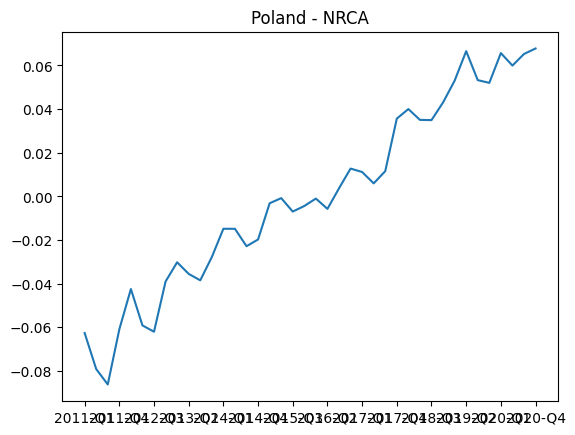

In [17]:
# The next step is to calculate the classic task content intensity.
# Here, we're looking at non-routine cognitive analytical tasks.

import matplotlib.pyplot as plt

index_name = "NRCA"

for country in COUNTRIES:
    standardized_columns = [f"std_{country}_{task}" for task in task_variables]

    combined[f"{country}_{index_name}"] = combined[standardized_columns].sum(axis=1)

    combined[f"std_{country}_{index_name}"] = weighted_standardize(
        combined[f"{country}_{index_name}"],
        combined[f"share_{country}"])

    combined[f"multip_{country}_{index_name}"] = (
        combined[f"std_{country}_{index_name}"] * combined[f"share_{country}"])

aggregated_data = {}
for country in COUNTRIES:
    aggregated_data[country] = (
        combined.groupby("TIME")[f"multip_{country}_{index_name}"]
        .sum()
        .reset_index())

for country in COUNTRIES:
    y_col = f"multip_{country}_{index_name}"
    plt.plot(aggregated_data[country]["TIME"], aggregated_data[country][y_col])
    plt.xticks(
        range(0, len(aggregated_data[country]), 3),
        aggregated_data[country]["TIME"][::3])
    plt.title(f"{country} - {index_name}")
    plt.show()

# If this code gets automated and cleaned properly,
# you should be able to easily add other countries as well as other tasks.
